In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

clima_poa = pd.read_excel('RIVER_data/DATA_POA.xlsx')
pd.set_option('future.no_silent_downcasting', True)

In [6]:
clima_poa['Data'] = clima_poa['DATA (YYYY-MM-DD)'].astype(str) + ' ' + clima_poa['HORA (UTC)'].astype(str)
clima_poa['Data'] = pd.to_datetime(clima_poa['Data'])
clima_poa.set_index('Data', inplace=True)
clima_poa.drop(columns=['DATA (YYYY-MM-DD)', 'HORA (UTC)'], inplace=True)

In [7]:
for col in clima_poa.columns:
    if clima_poa[col].dtype == 'object':
        print(f'Converting {col} to numeric')
        clima_poa[col] = pd.to_numeric(clima_poa[col], errors='coerce')

clima_poa = clima_poa.replace(-9999, 0)
clima_poa = clima_poa.replace('-', 0)

Converting TEMPERATURA DO PONTO DE ORVALHO (°C) to numeric
Converting TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C) to numeric
Converting TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C) to numeric
Converting UMIDADE REL. MIN. NA HORA ANT. (AUT) (%) to numeric
Converting UMIDADE RELATIVA DO AR to numeric
Converting HORARIA (%) to numeric
Converting VENTO to numeric
Converting DIREÇÃO HORARIA (gr) (° (gr)) to numeric


In [10]:
def contar_nulos_vazios_zeros(df):
    resultados = {}
    total_linhas = len(df)
    for col in df.columns:
        nulos = df[col].isnull().sum()
        vazios = (df[col] == '').sum() if df[col].dtype == object else 0
        zeros = (df[col] == 0).sum() if np.issubdtype(df[col].dtype, np.number) else 0
        resultados[col] = {'nulos': nulos, 'vazios': vazios, 'zeros': zeros, 'total_linhas': total_linhas}
    return pd.DataFrame(resultados).T

contagem = contar_nulos_vazios_zeros(clima_poa)
print(contagem)

                                                  nulos  vazios  zeros  \
PRECIPITAÇÃO TOTAL                                 3292       0  58958   
HORÁRIO (mm)                                        242       0     43   
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO             243       0     43   
HORARIA (mB)                                        252       0     45   
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)     282       0     56   
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)   1629       0    508   
RADIACAO GLOBAL (KJ/m²)                            3610       0   1288   
TEMPERATURA DO AR - BULBO SECO                    16286       0   5989   
HORARIA (°C)                                       1611       0    571   
TEMPERATURA DO PONTO DE ORVALHO (°C)                266       0     44   
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)          302       0     44   
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)          310       0     46   
TEMPERATURA ORVALHO MAX. NA HORA ANT. 

In [15]:
clima_poa.describe()

,PRECIPITAÇÃO TOTAL,HORÁRIO (mm),PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO,HORARIA (mB),PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (KJ/m²),TEMPERATURA DO AR - BULBO SECO,HORARIA (°C),TEMPERATURA DO PONTO DE ORVALHO (°C),...,UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),UMIDADE RELATIVA DO AR,HORARIA (%),VENTO,DIREÇÃO HORARIA (gr) (° (gr)),VENTO.1,RAJADA MAXIMA (m/s),VENTO.2,VELOCIDADE HORARIA (m/s)
count,61700.000000,64750.000000,64749.000000,64740.000000,64710.000000,63363.000000,61382.000000,48706.000000,63381.000000,64726.000000,...,64734.000000,64712.000000,64705.000000,64627.000000,64628.000000,64637.000000,64690.000000,64615.000000,64311.000000,63377.000000
mean,0.156499,929.210965,176.166582,878.133272,199.860022,854.963496,179.511143,670.232826,21.802638,12.964249,...,11.947385,12.115234,11.159091,13.643384,20.908724,36.874623,62.828412,80.291712,82.207087,78.135727
std,1.131945,272.393349,377.513387,338.975576,400.395713,440.516492,517.592214,1007.725069,101.089792,8.874990,...,7.918093,8.556766,9.784391,16.182219,27.242199,37.962687,40.434902,43.193636,62.210265,83.959049
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-3.000000,-3.000000,-3.000000,-5.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1004.000000,3.000000,1004.000000,3.000000,1002.000000,3.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,6.000000,20.000000,62.000000,53.000000,5.000000
50%,0.000000,1009.000000,6.000000,1008.000000,6.000000,1007.000000,6.000000,25.000000,9.000000,11.000000,...,9.000000,9.000000,9.000000,9.000000,10.000000,16.000000,75.000000,80.000000,79.000000,66.000000
75%,0.000000,1013.000000,9.000000,1013.000000,9.000000,1012.000000,9.000000,1154.000000,19.000000,20.000000,...,19.000000,19.000000,16.000000,17.000000,19.000000,77.000000,89.000000,92.000000,95.000000,111.000000
max,47.000000,1030.000000,1028.000000,1030.000000,3686.000000,3982.000000,3970.000000,3999.000000,3757.000000,39.000000,...,100.000000,100.000000,341.000000,334.000000,349.000000,357.000000,360.000000,360.000000,360.000000,360.000000


In [11]:
def substituir_outliers_iqr(df, colunas=None, fator=1.5):

    if colunas is None:
        colunas = df.select_dtypes(include='number').columns

    df_corrigido = df.copy()
    for col in colunas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - fator * IQR
        lim_sup = Q3 + fator * IQR

        df_corrigido[col] = df_corrigido[col].apply(
            lambda x: lim_inf if x < lim_inf else (lim_sup if x > lim_sup else x)
        )
    
    return df_corrigido

clima_poa_iqr = substituir_outliers_iqr(clima_poa, clima_poa.columns, fator=1.2)

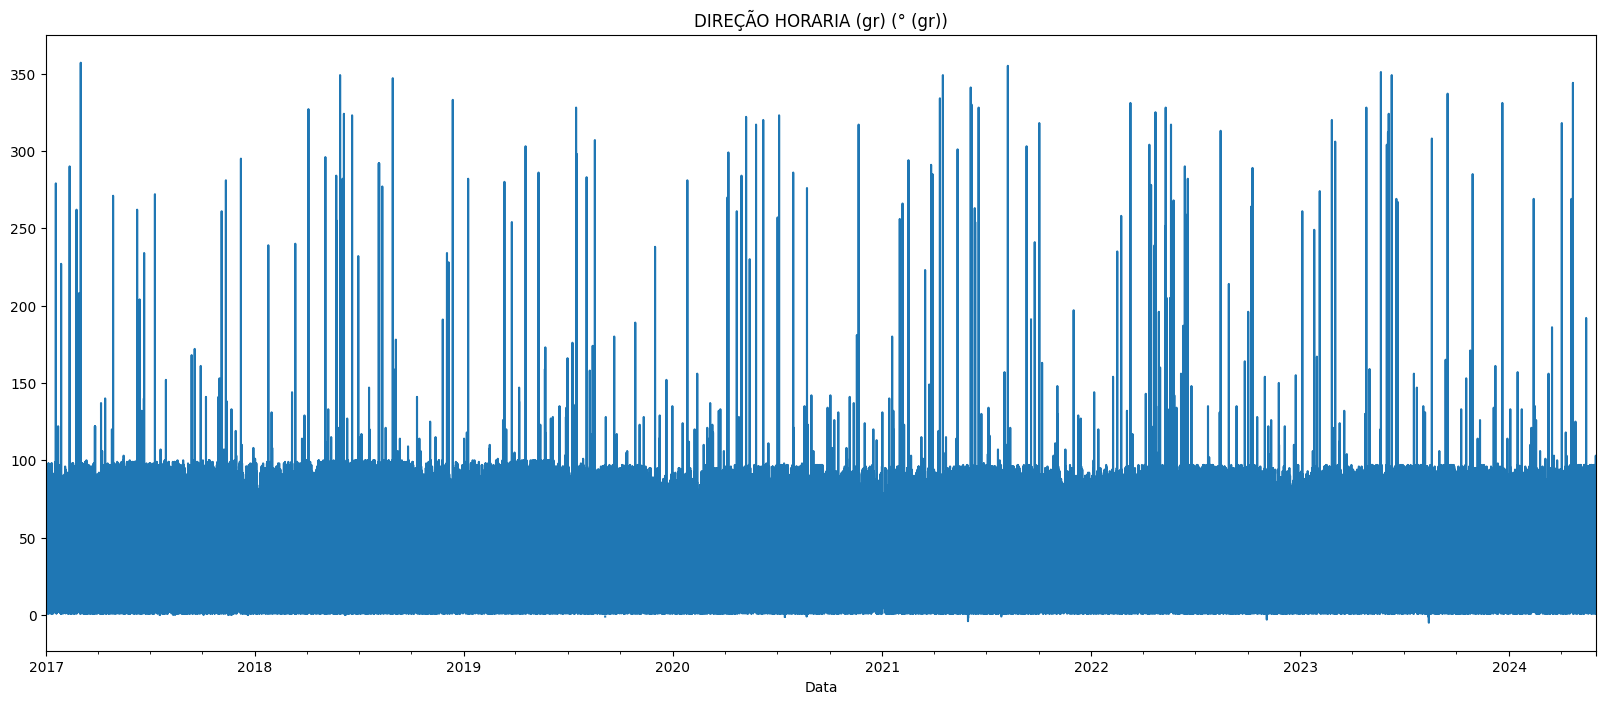

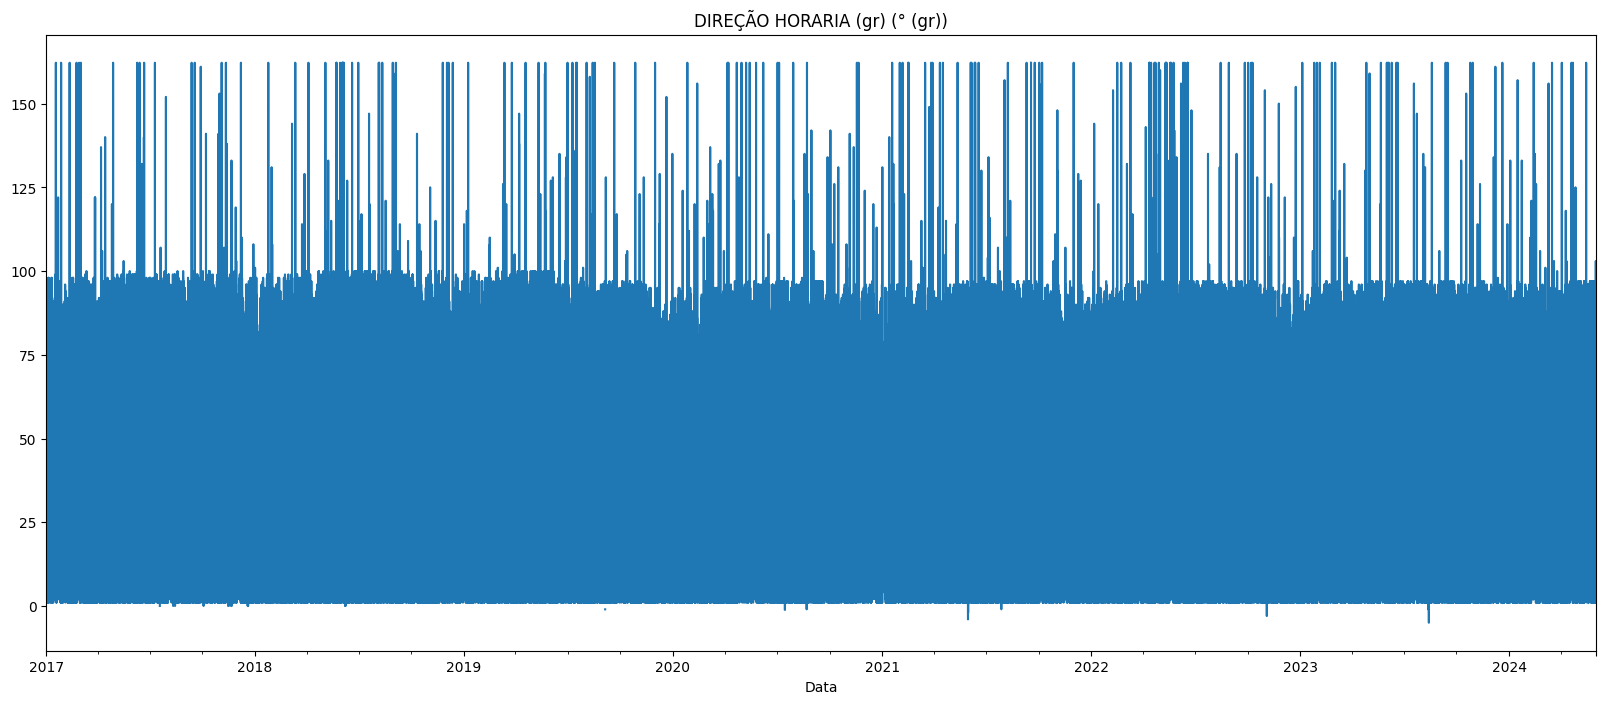

In [15]:
for col in clima_poa.columns:
    if col == 'DIREÇÃO HORARIA (gr) (° (gr))':
        plt.figure(figsize=(20, 8))  # Cria uma nova figura para cada coluna
        clima_poa[col].plot(title=col)  # Plota a coluna
        plt.show() 

        plt.figure(figsize=(20, 8))  # Cria uma nova figura para cada coluna
        clima_poa_iqr[col].plot(title=col)  # Plota a coluna
        plt.show() 

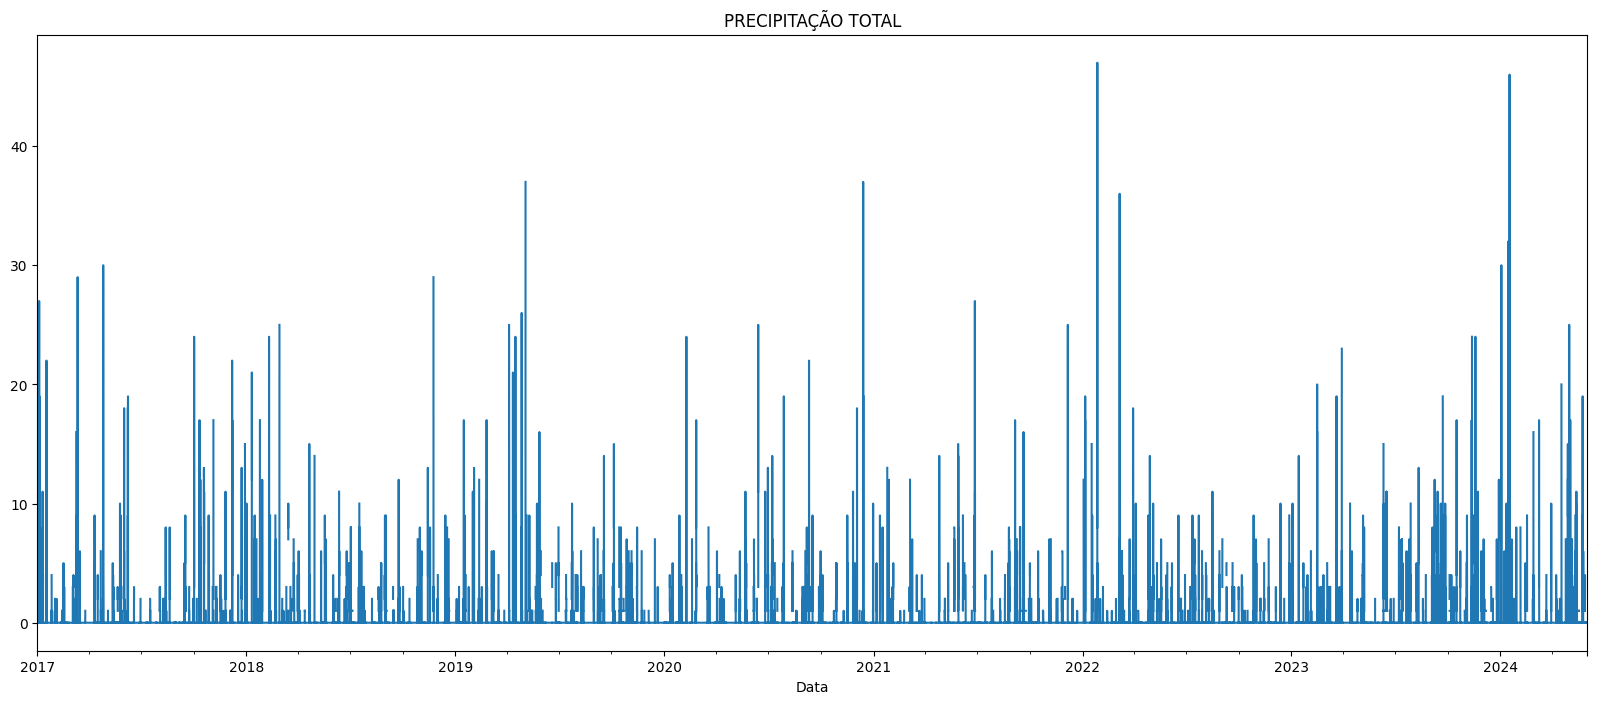

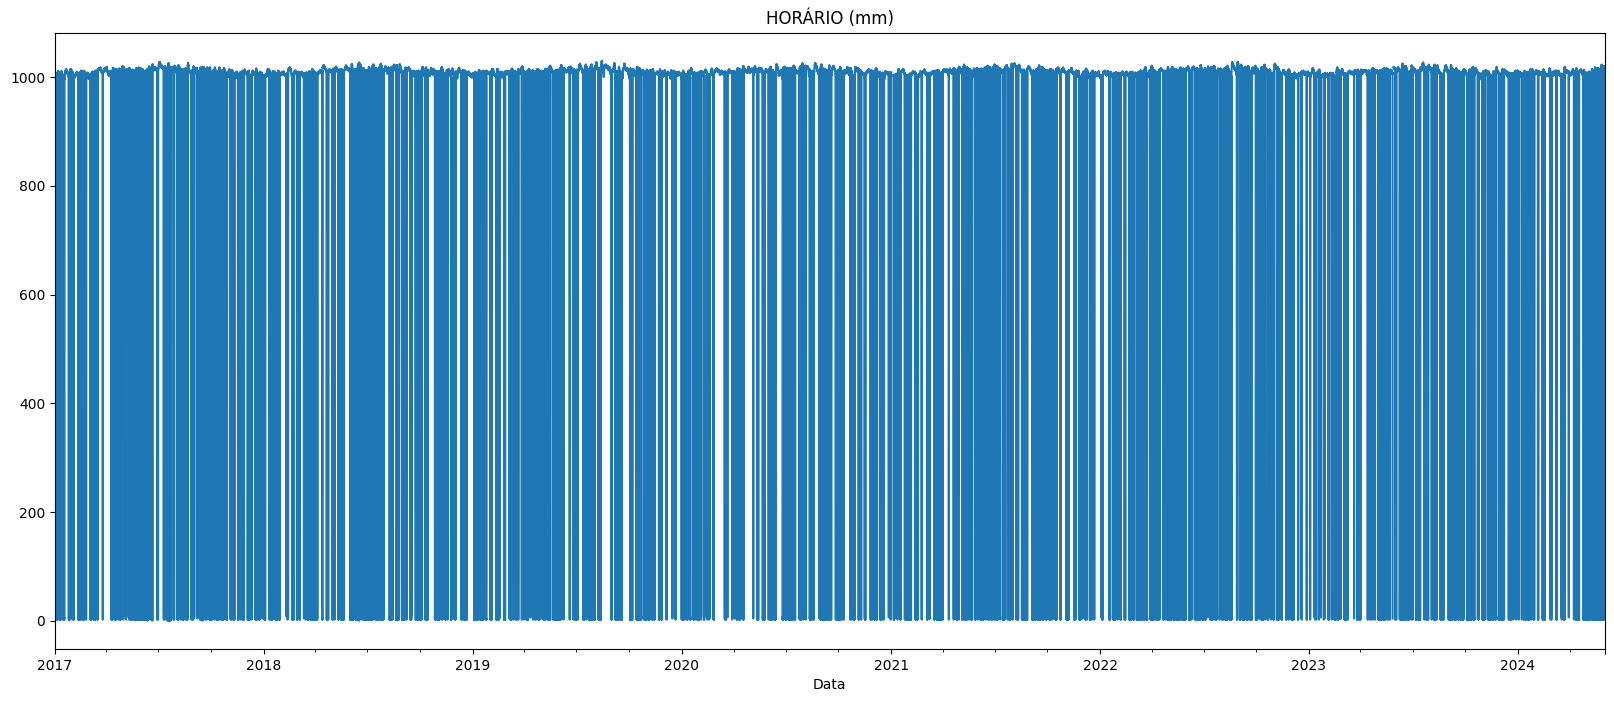

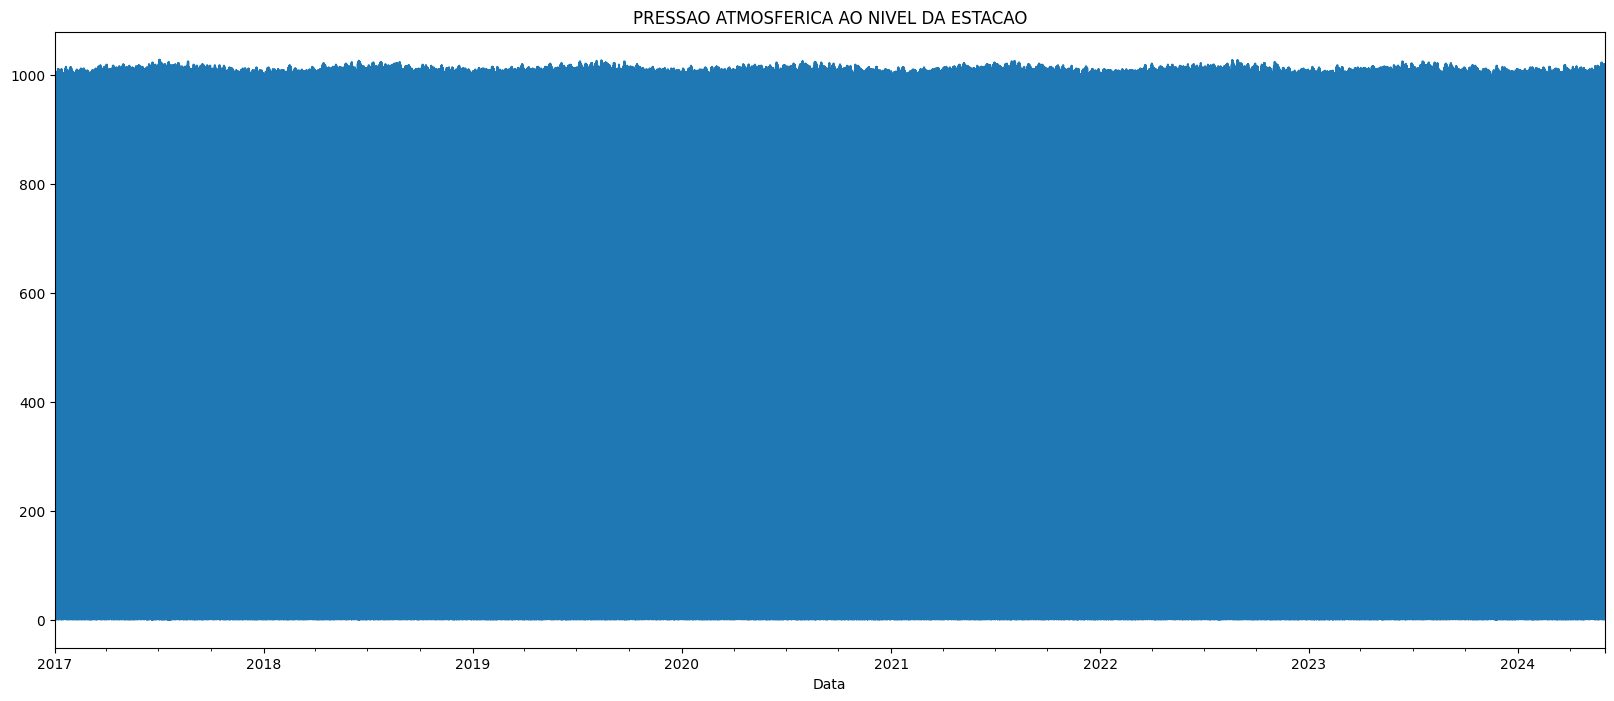

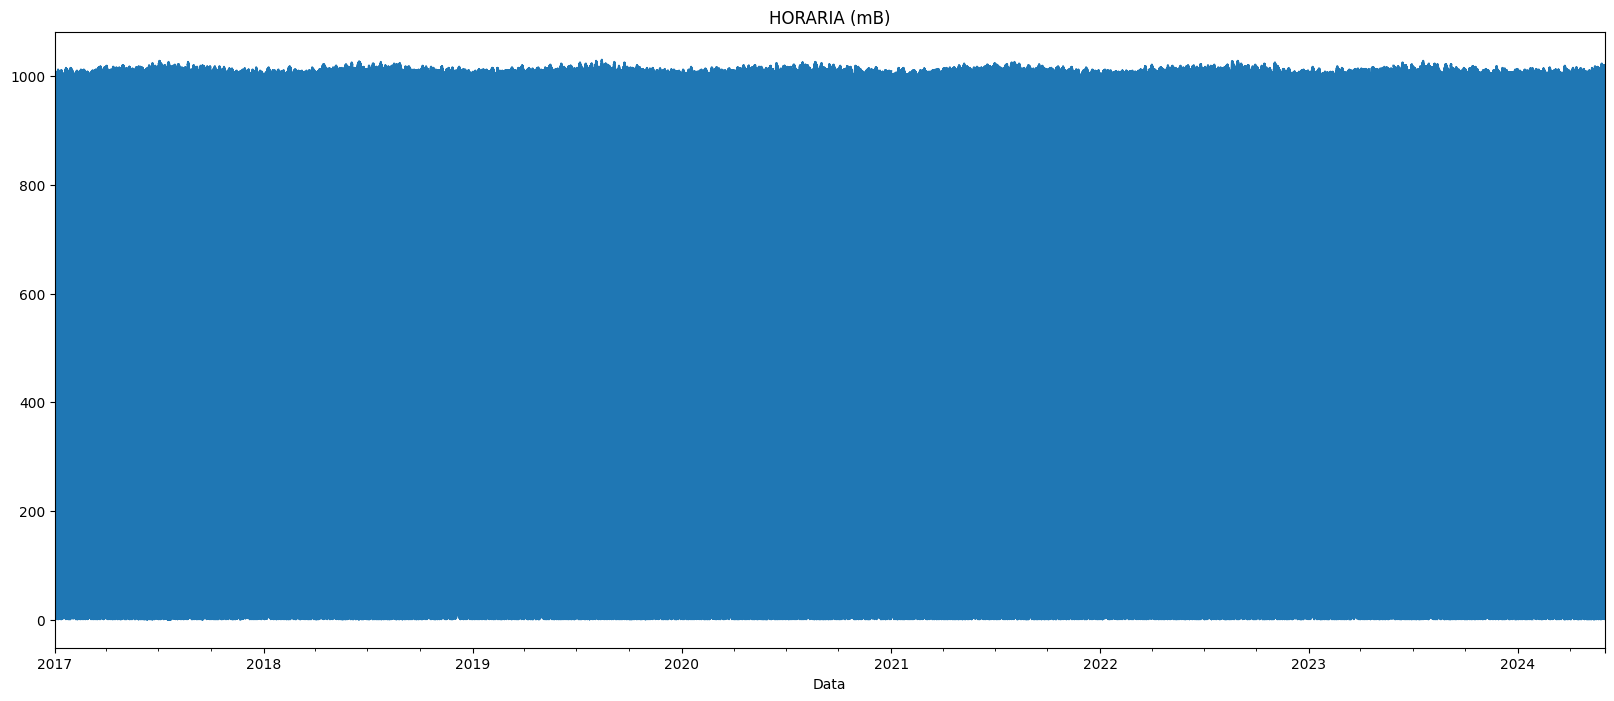

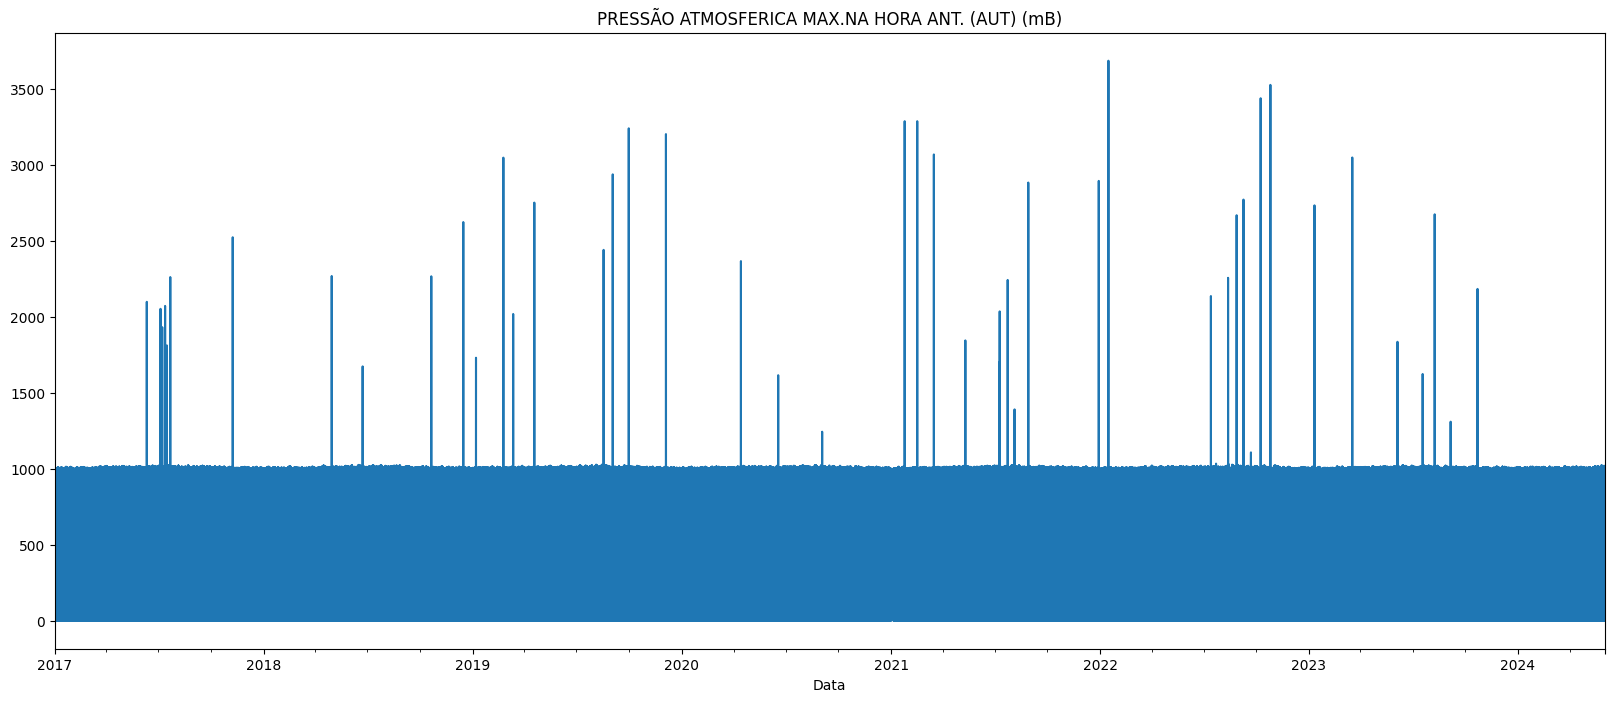

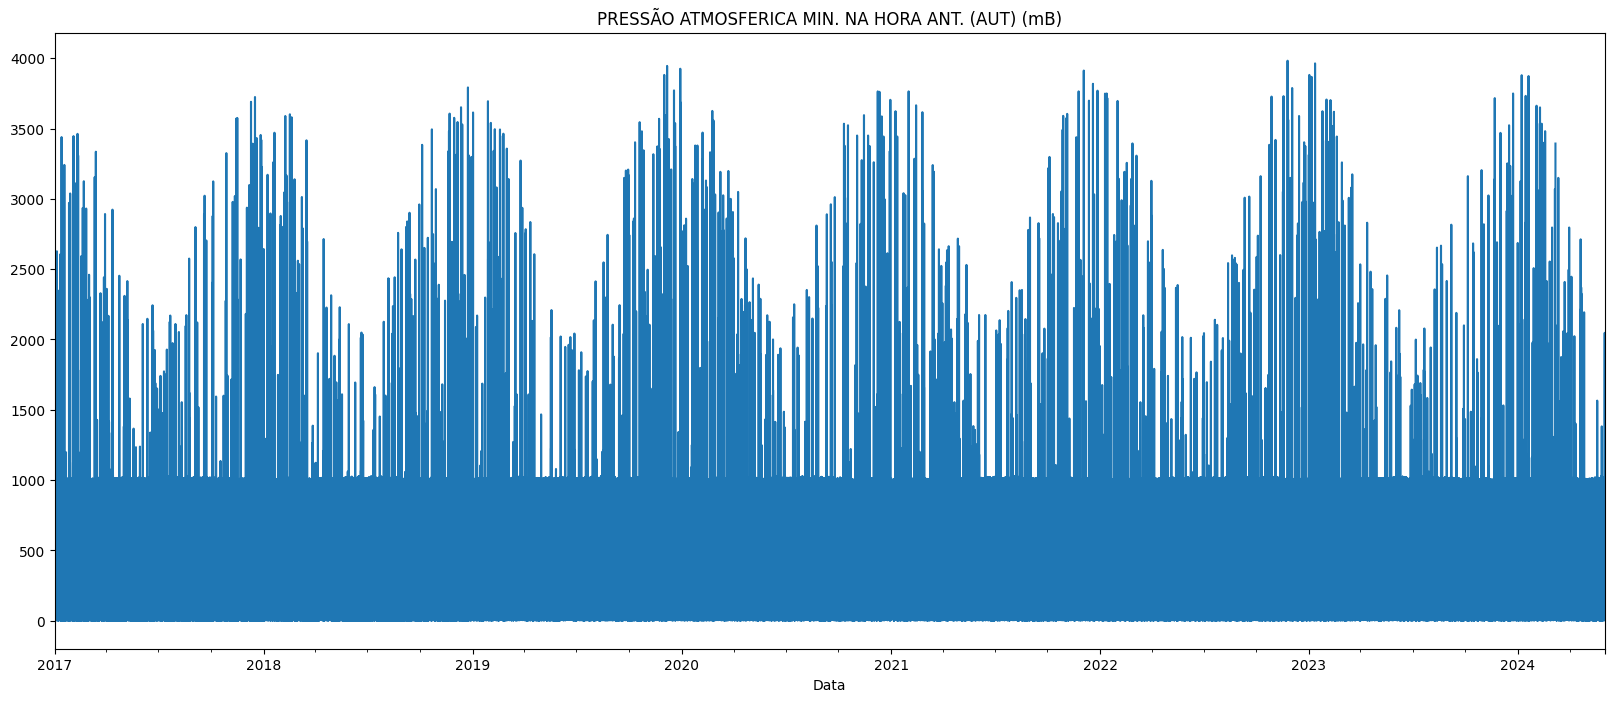

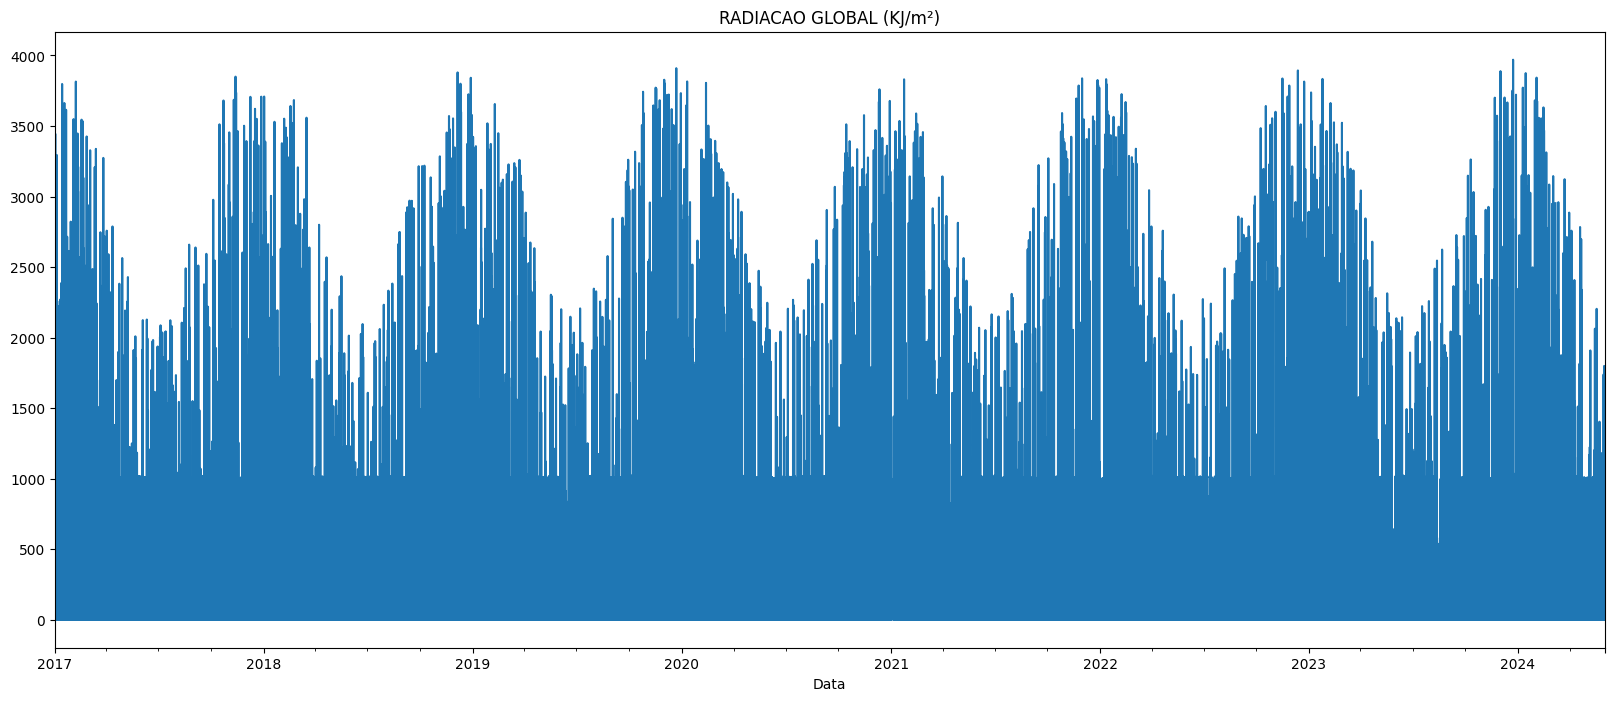

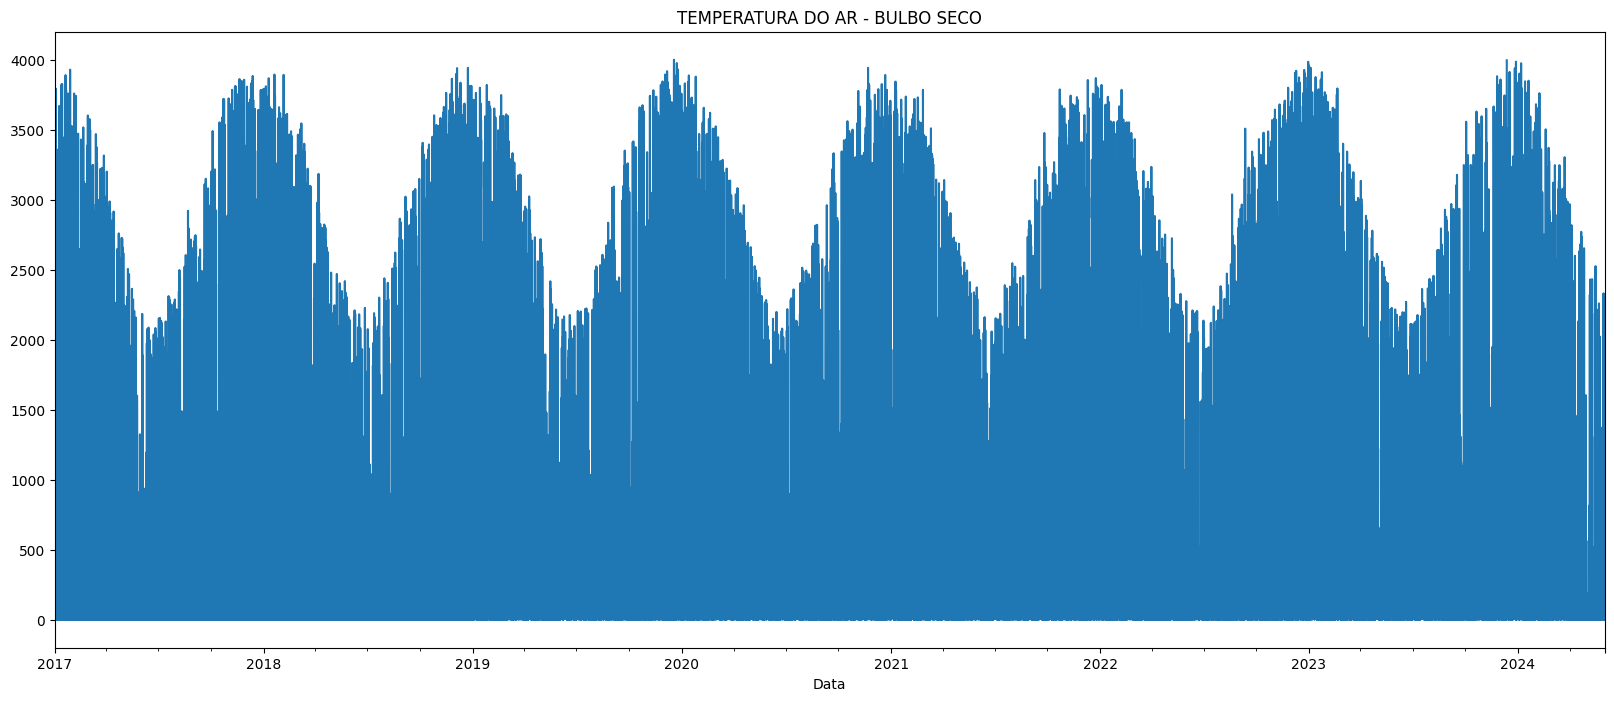

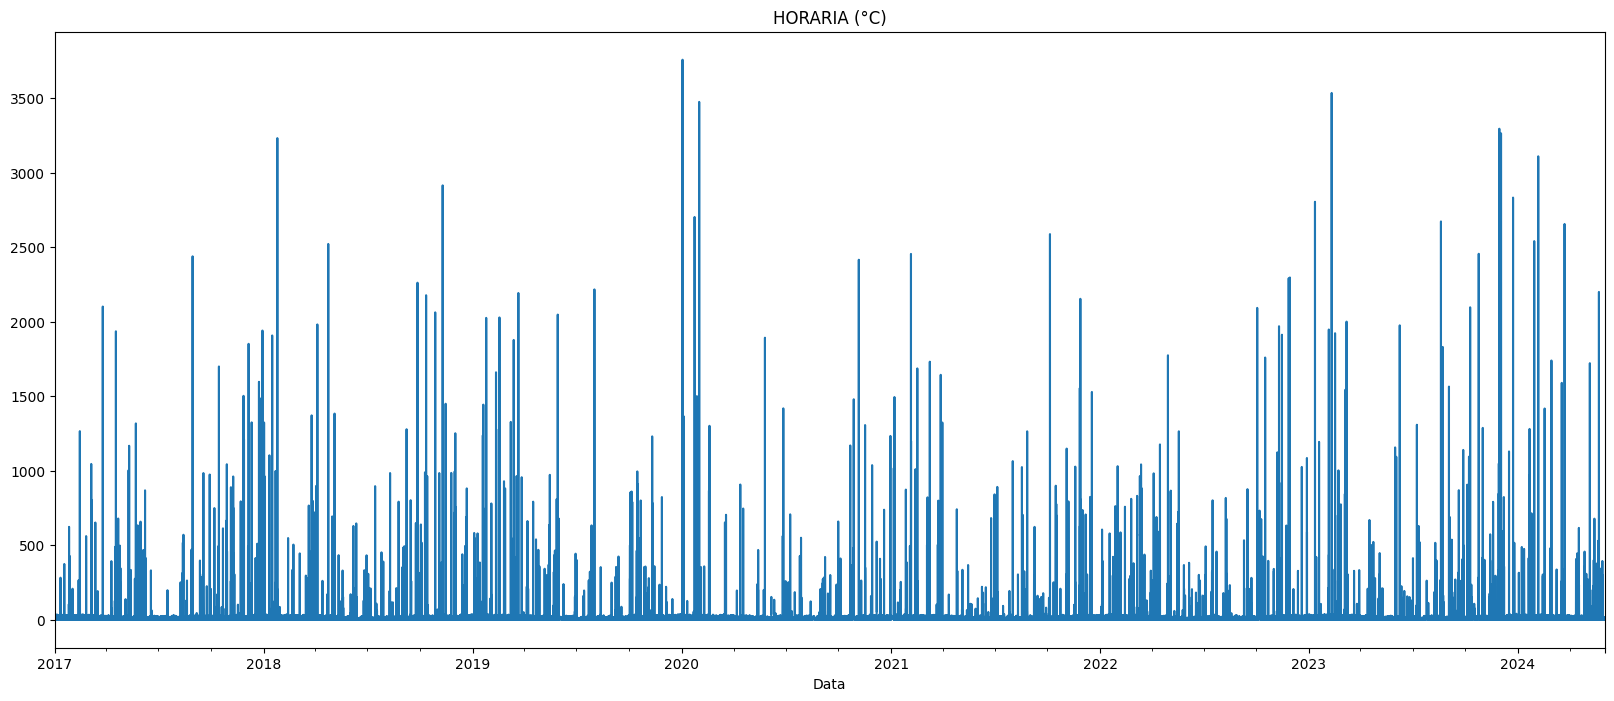

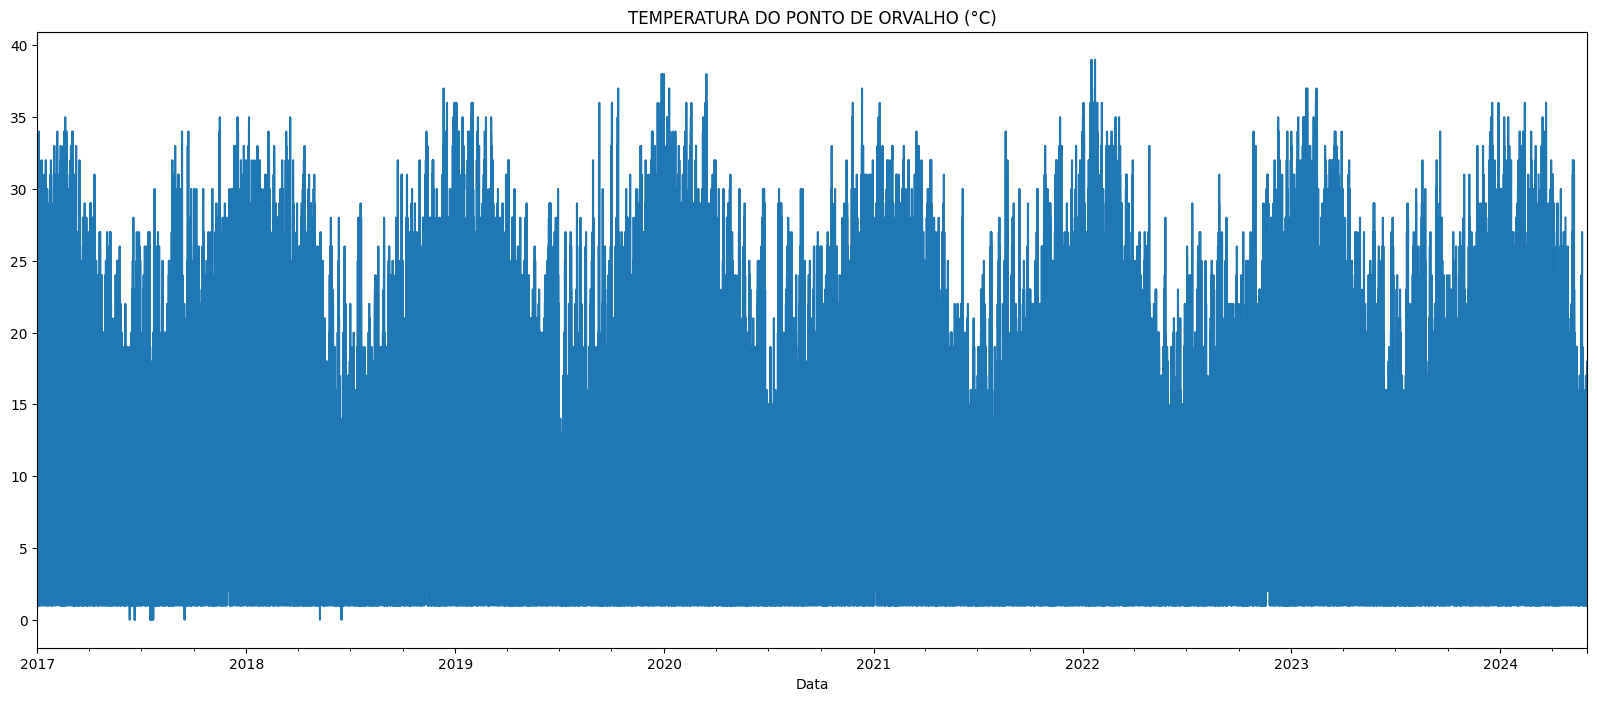

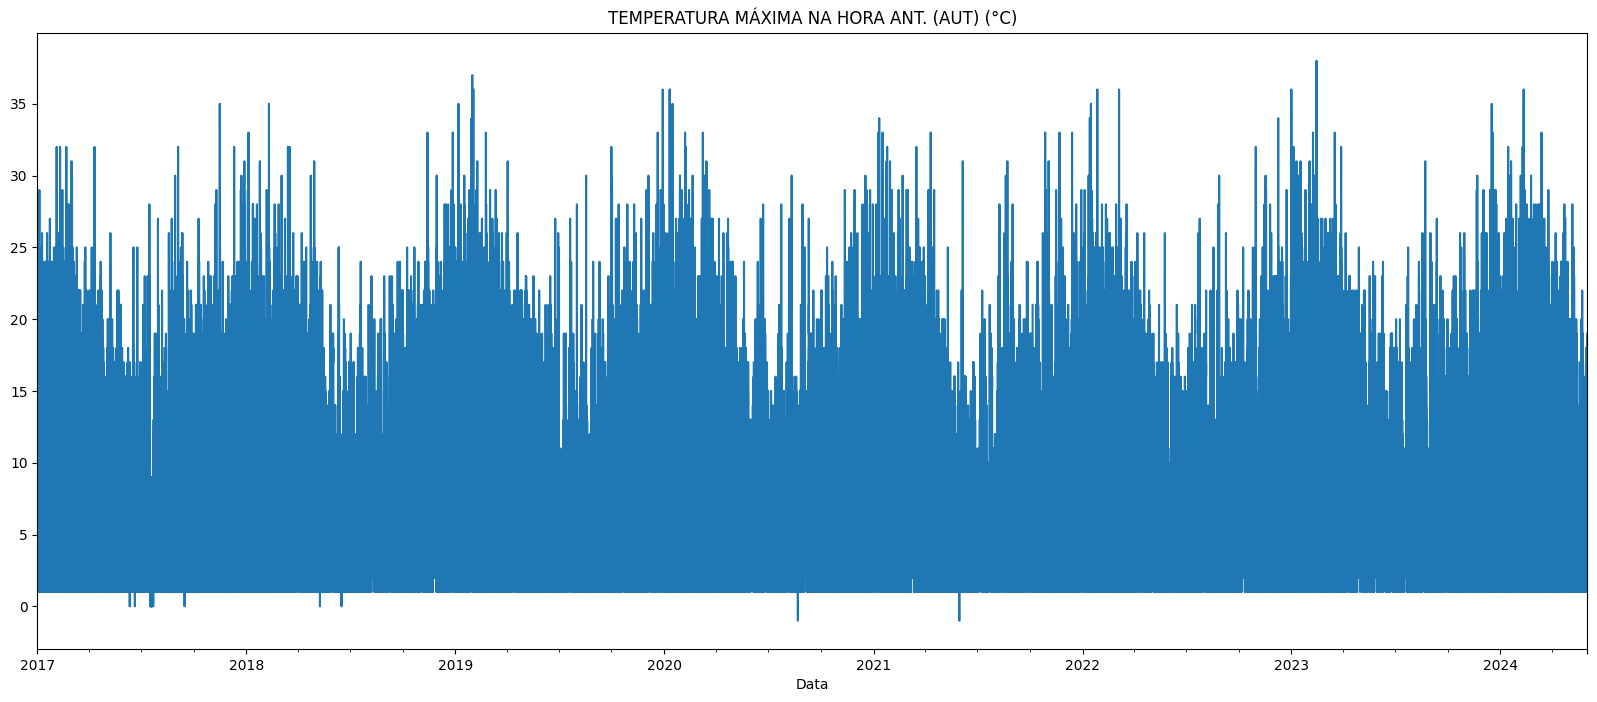

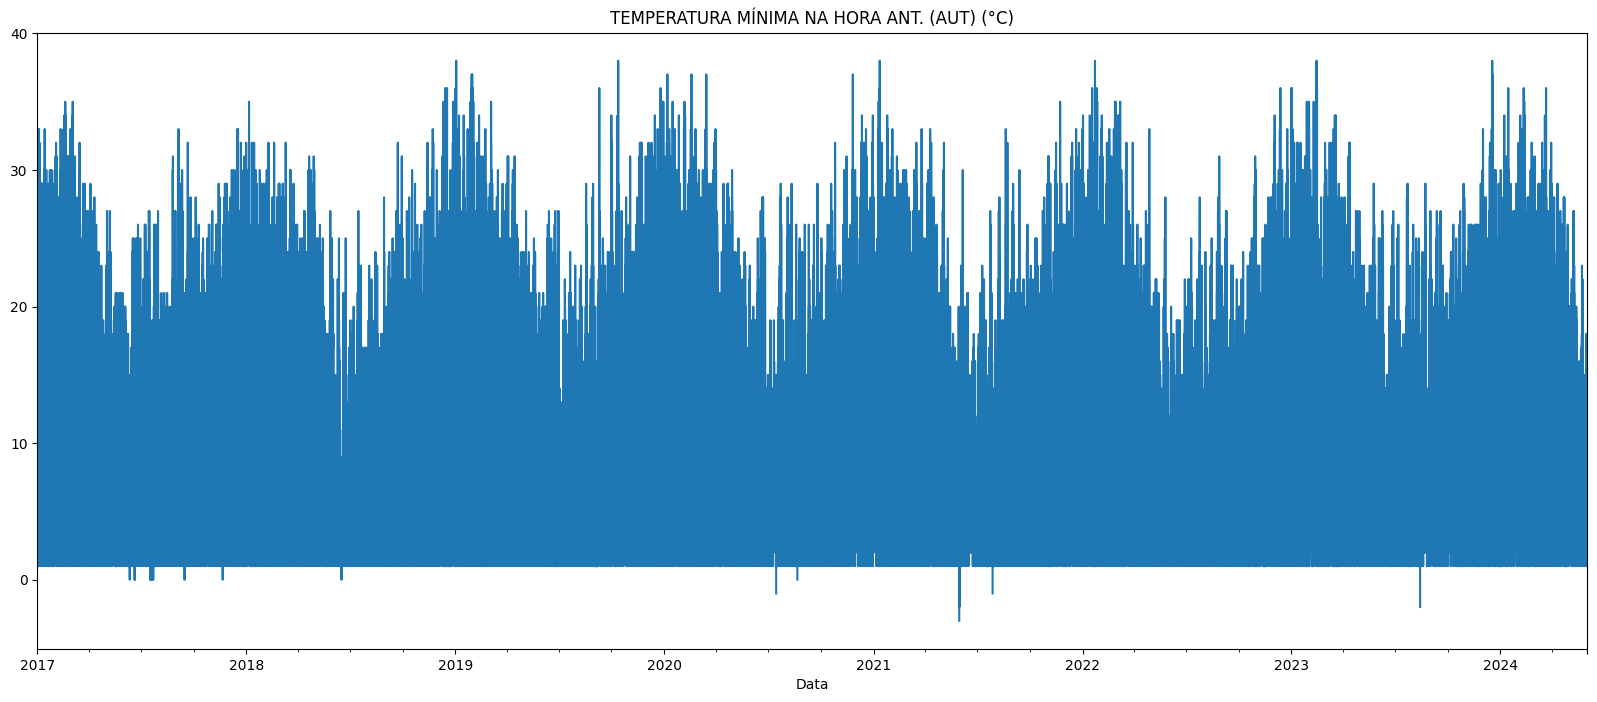

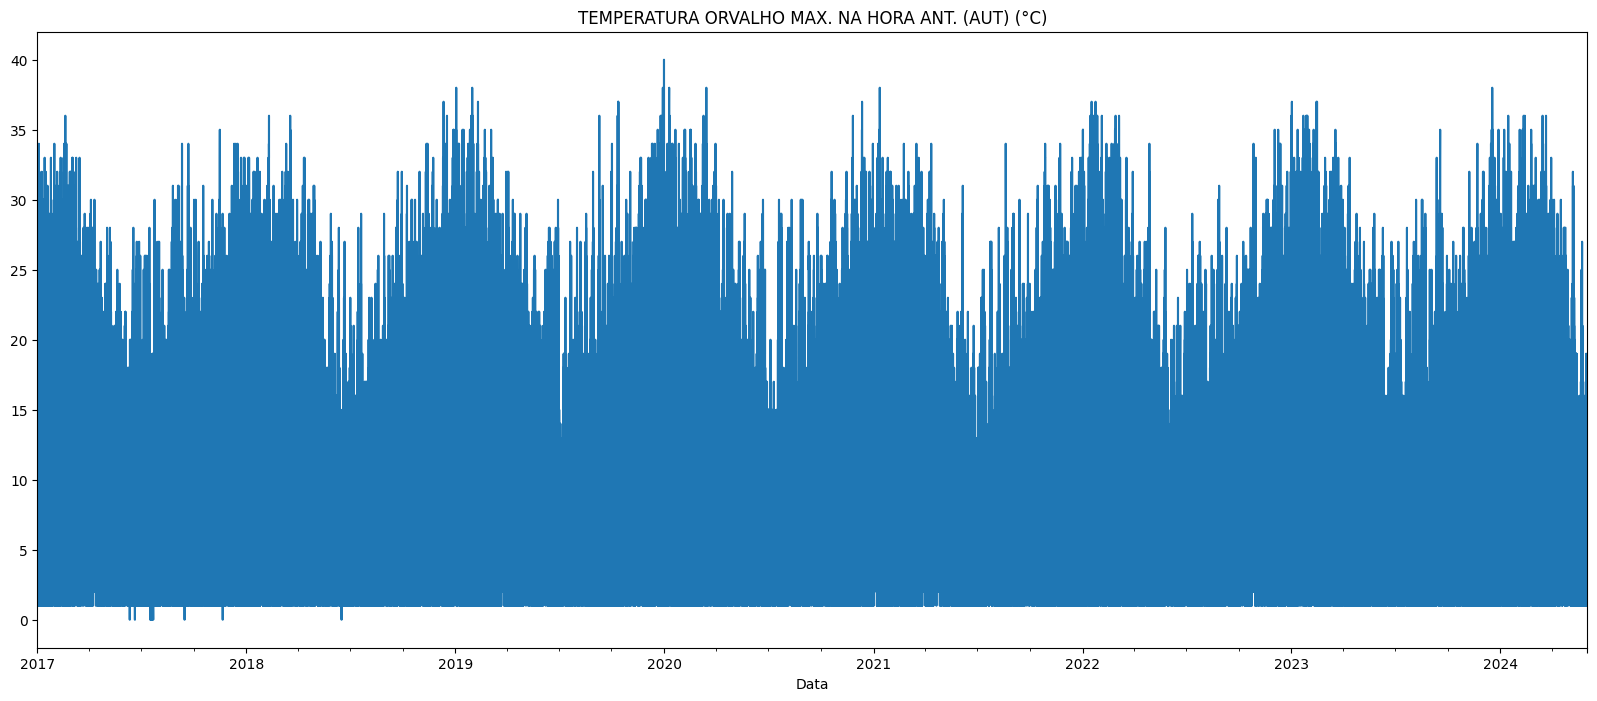

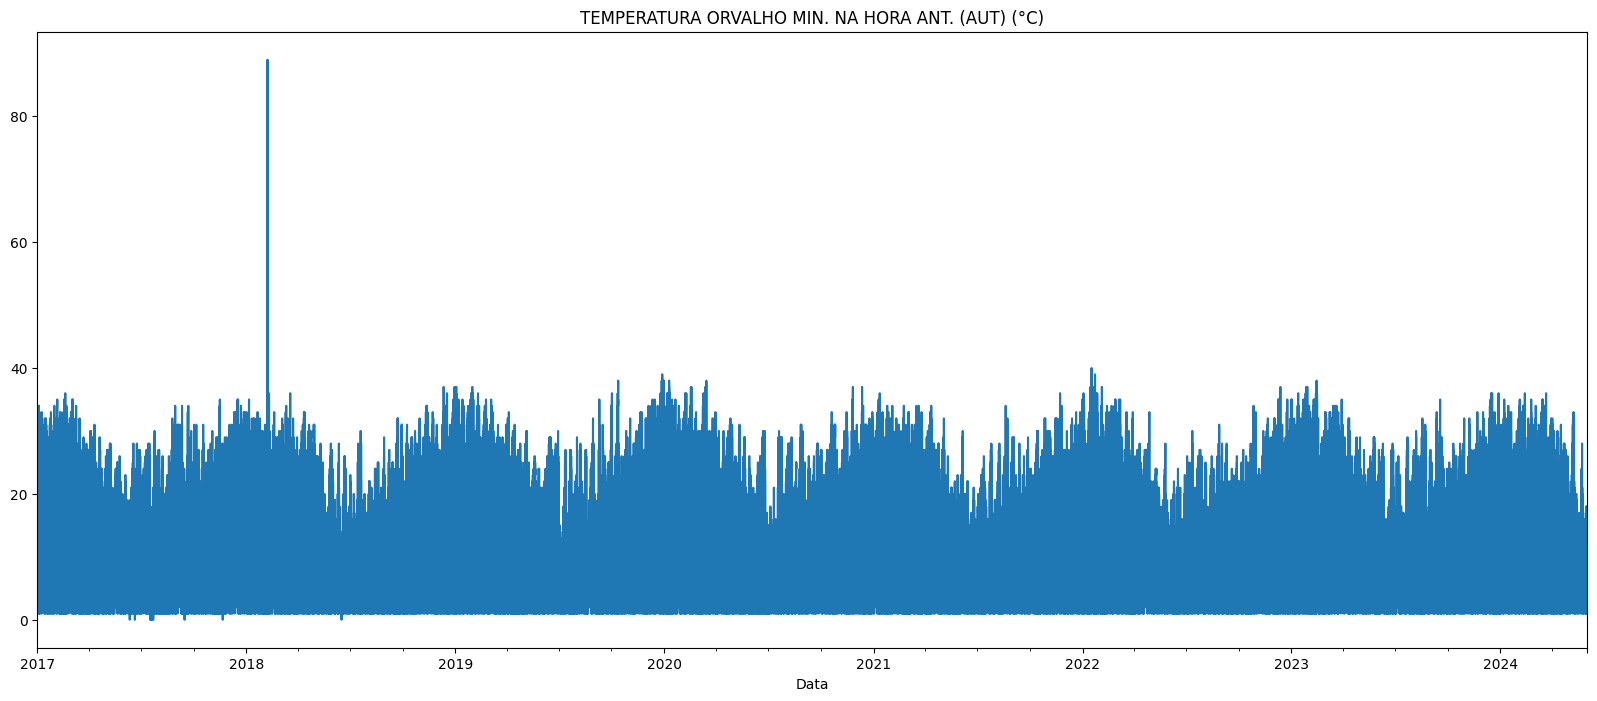

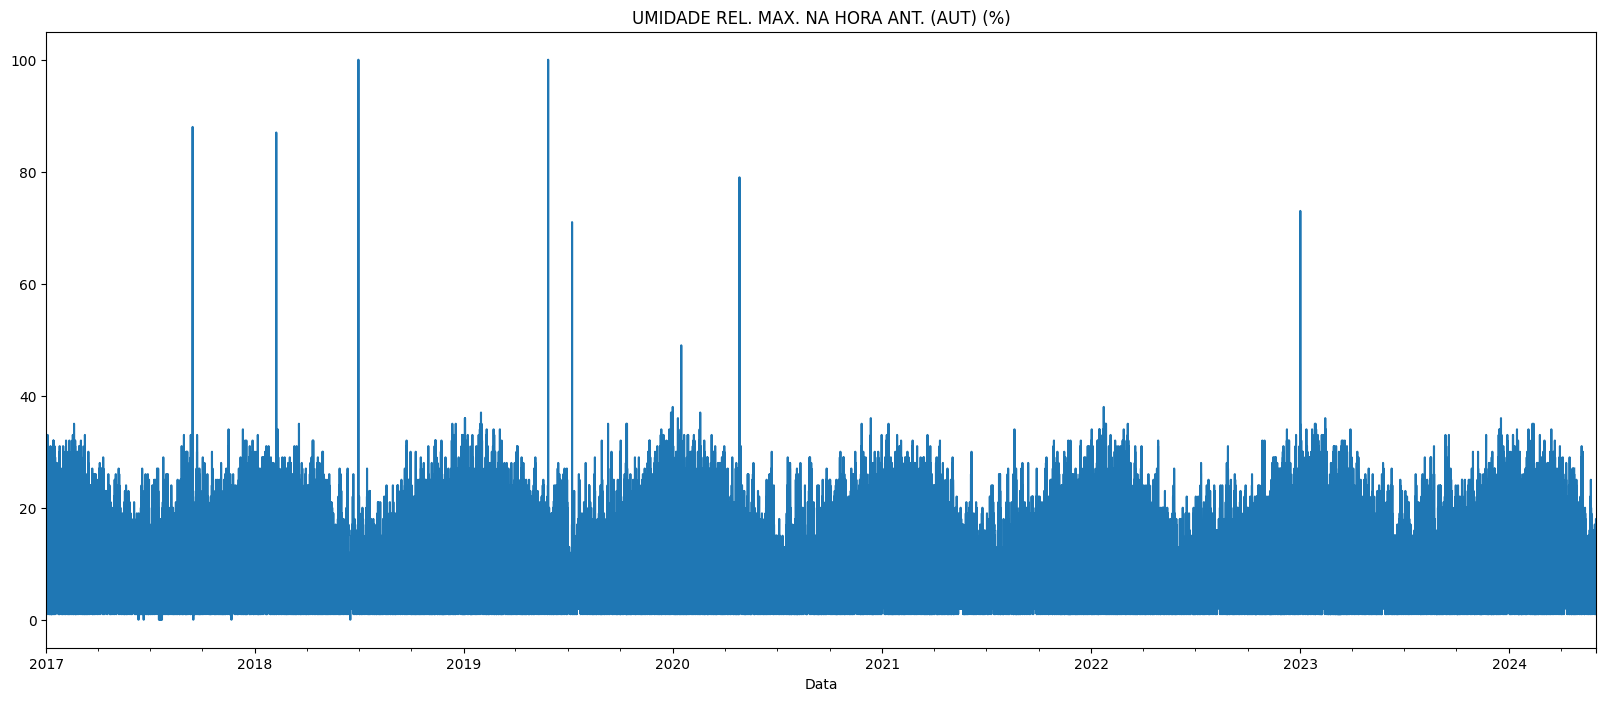

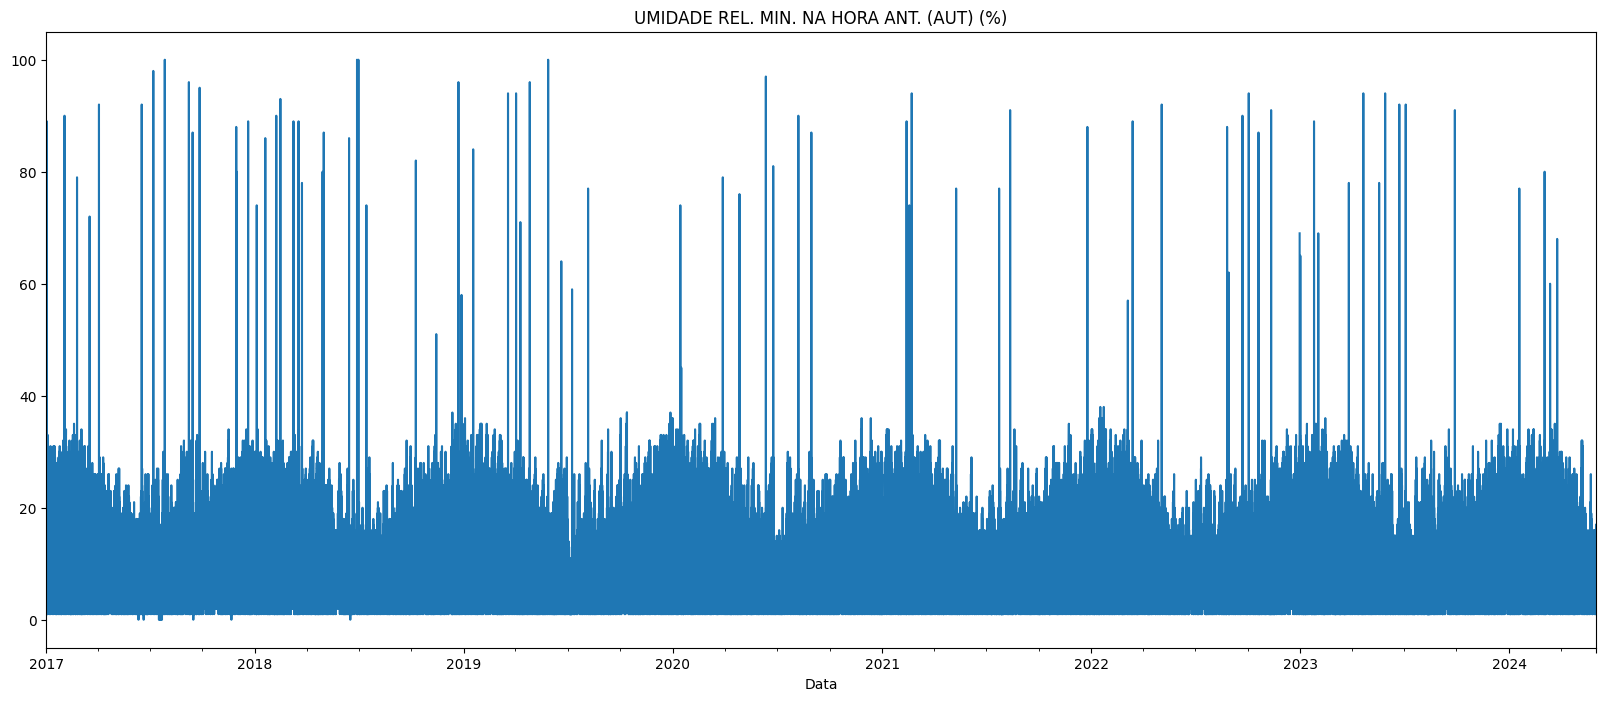

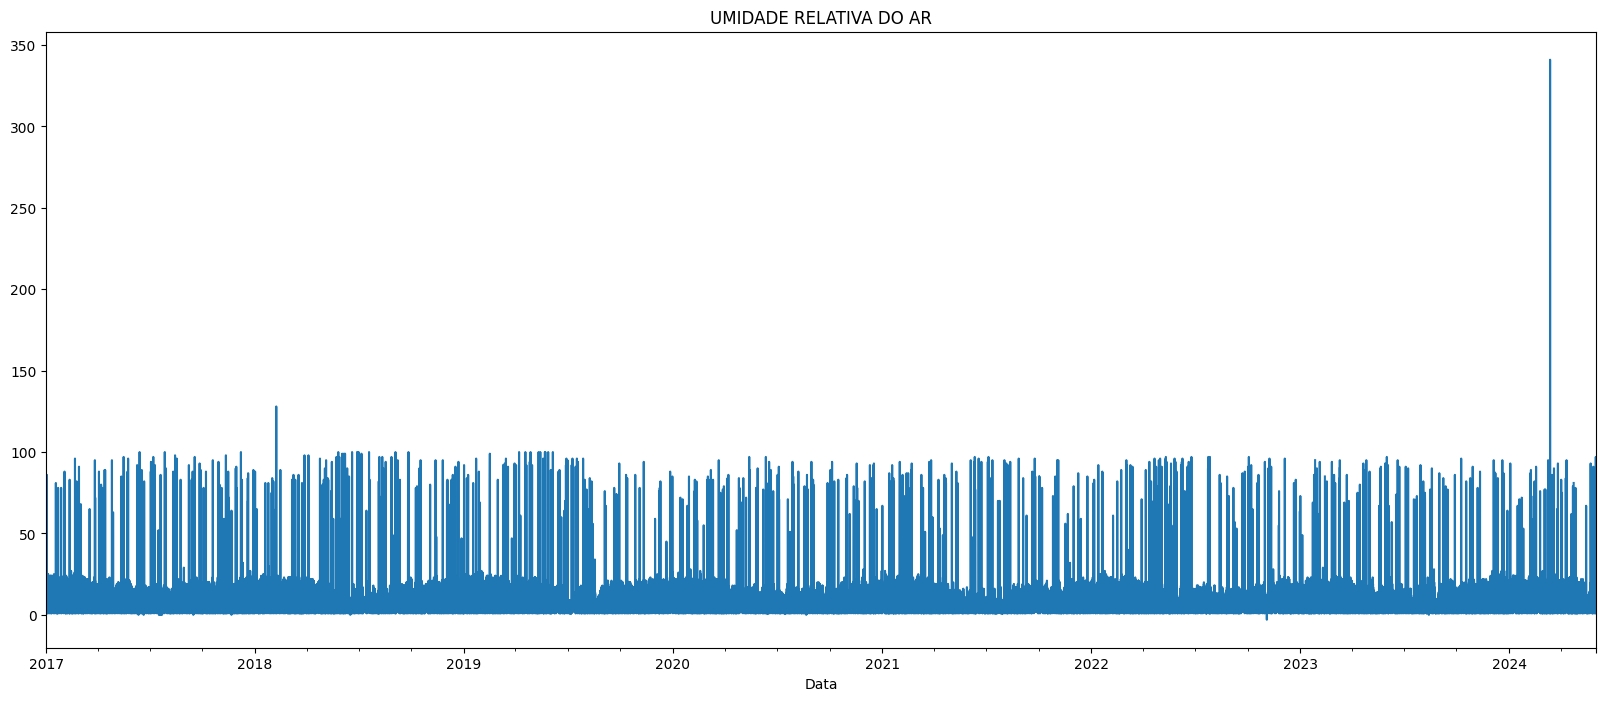

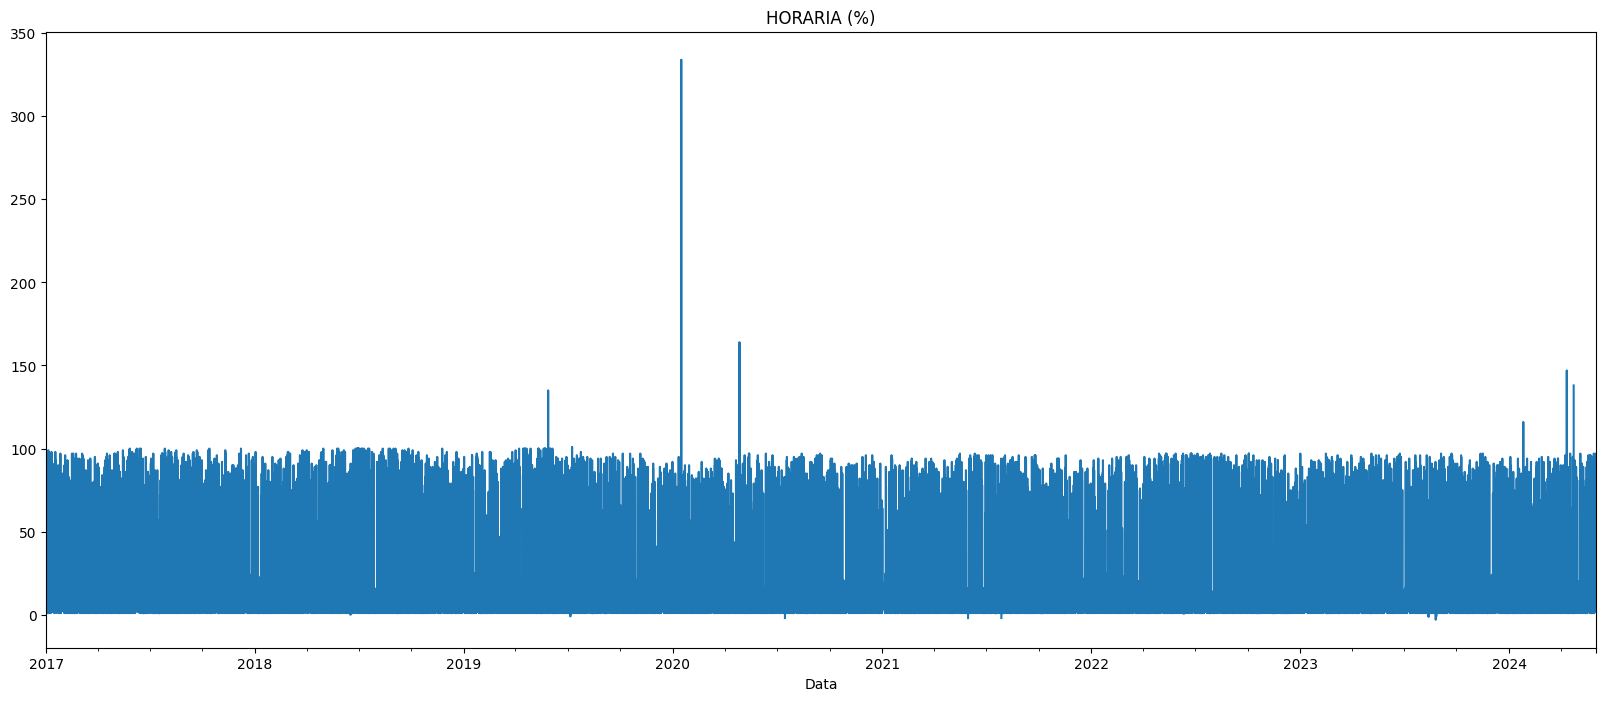

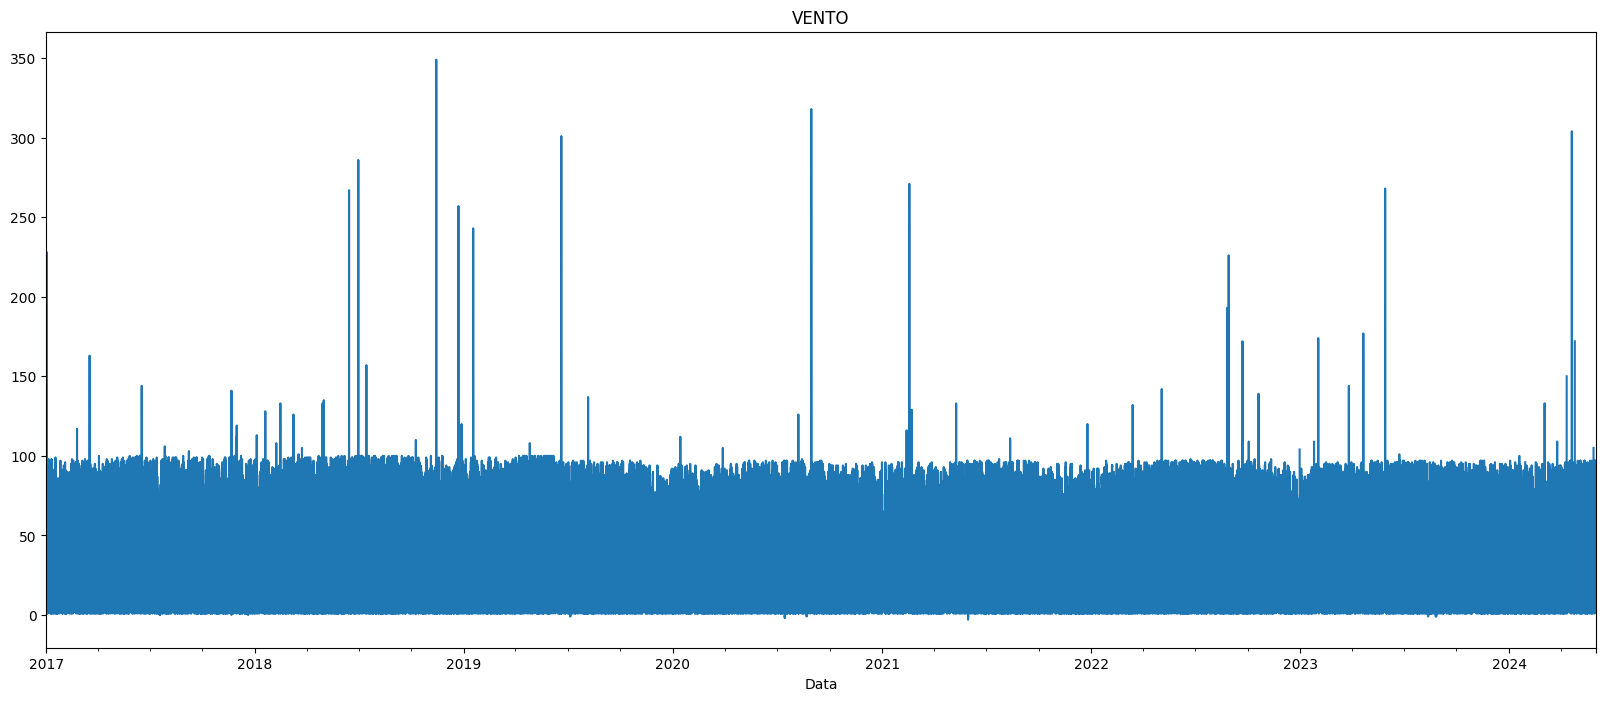

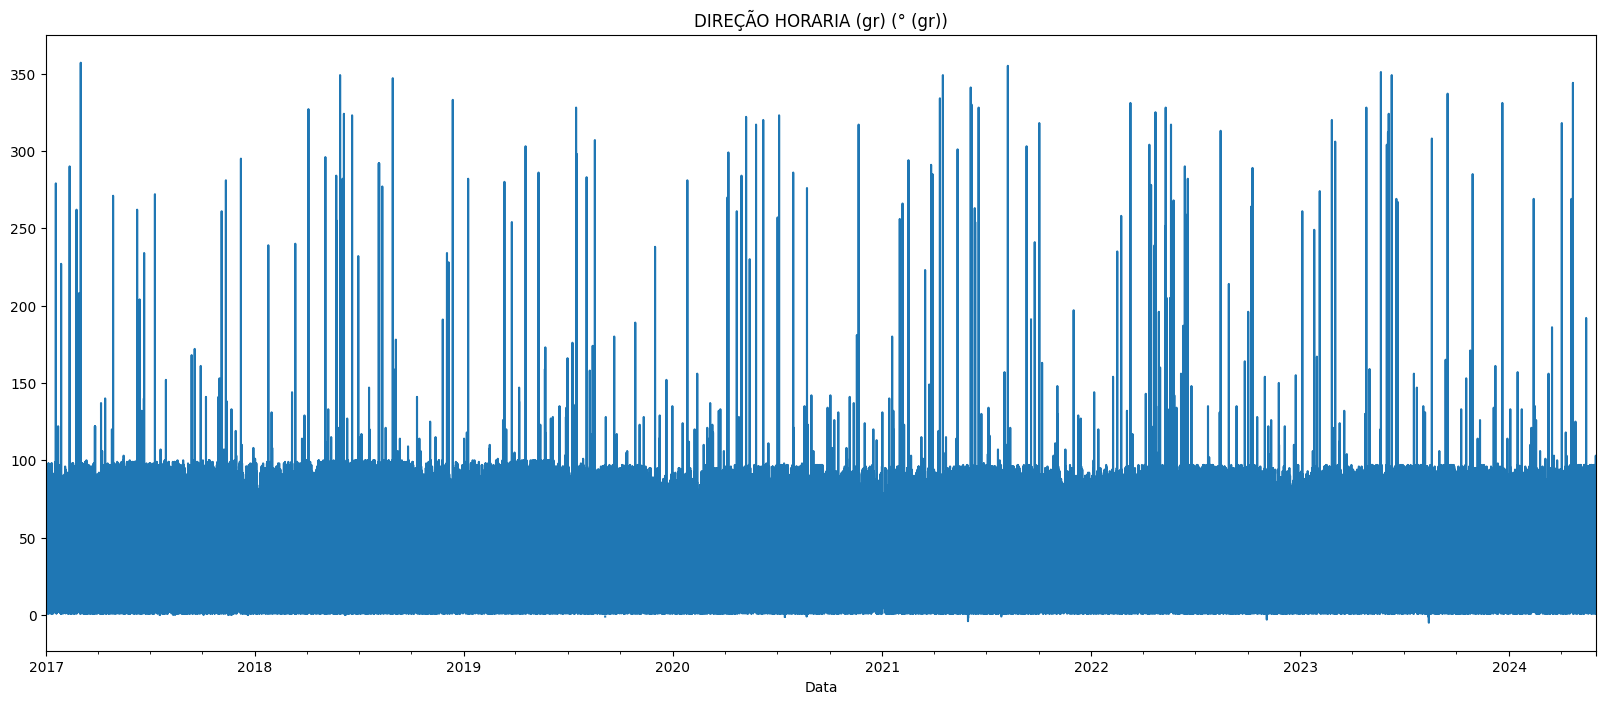

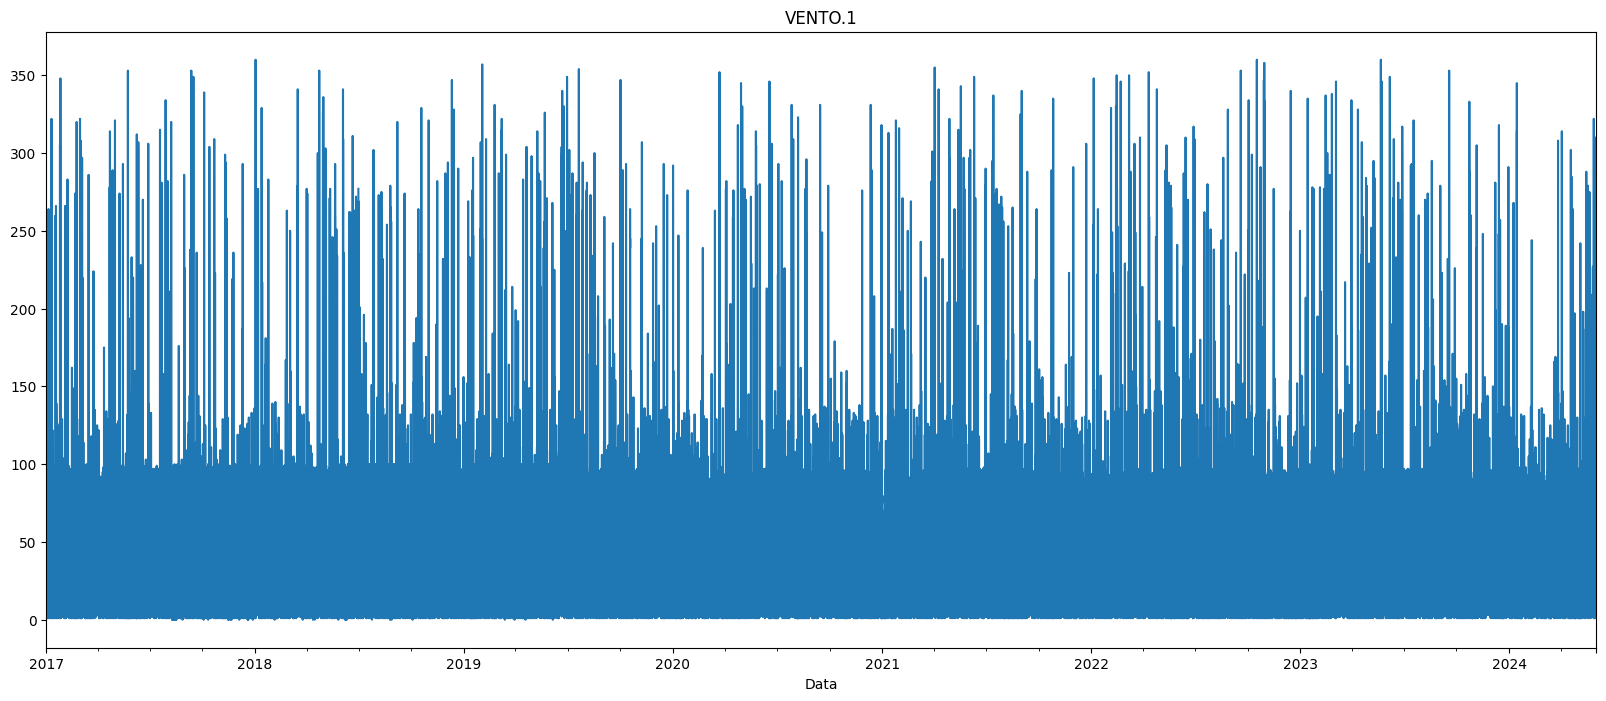

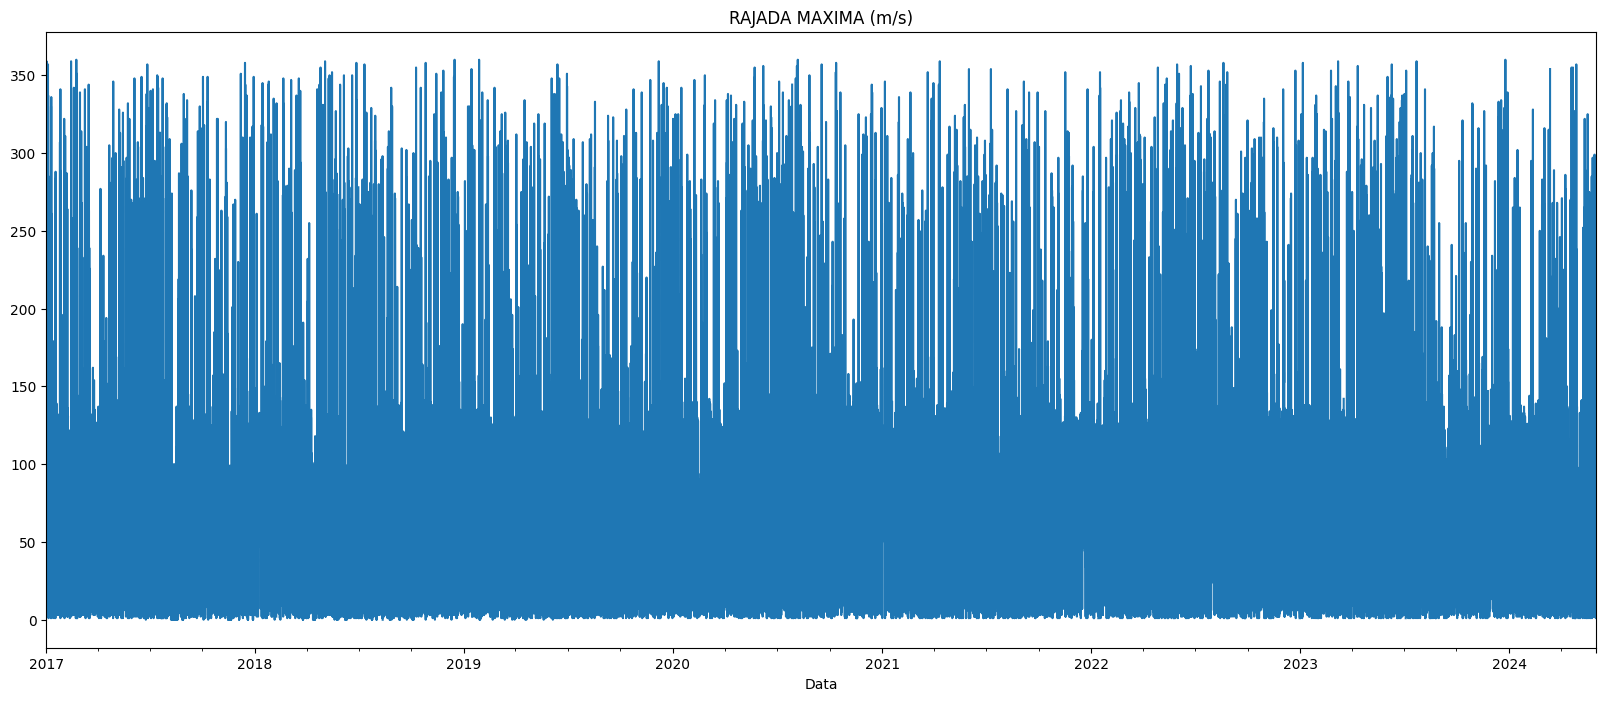

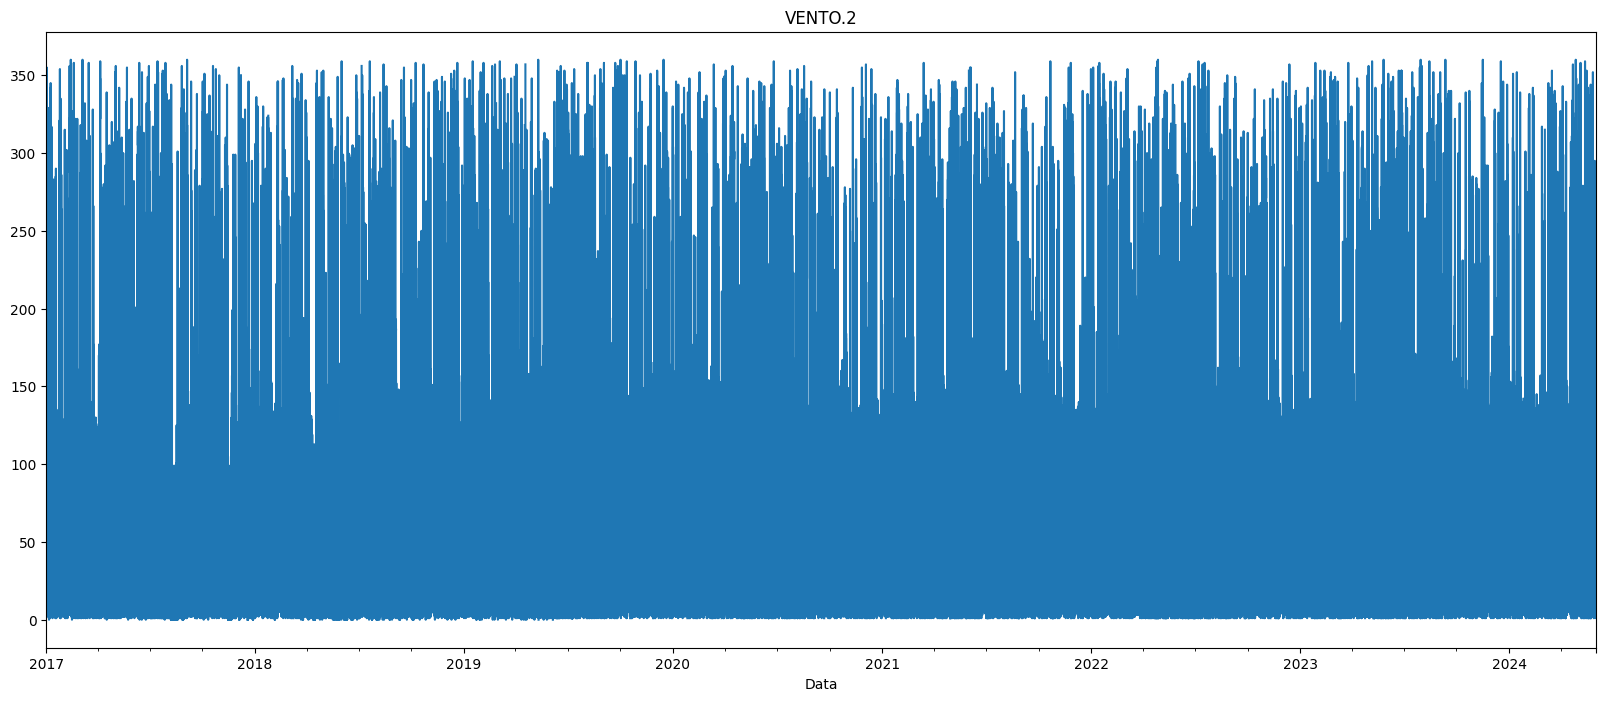

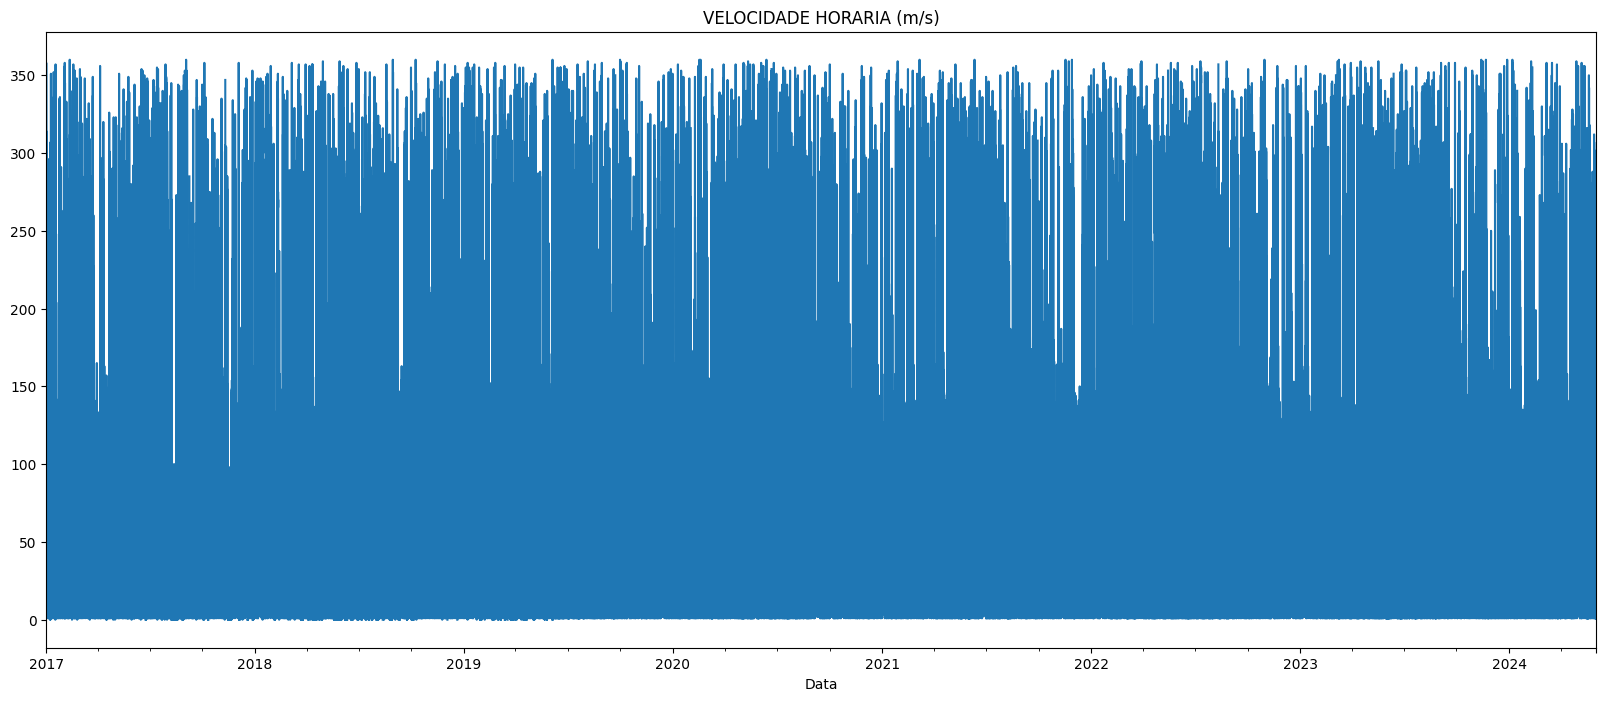

In [47]:
for col in clima_poa.columns:
    plt.figure(figsize=(20, 8))  # Cria uma nova figura para cada coluna
    clima_poa[col].plot(title=col)  # Plota a coluna
    plt.show() 
    

<Figure size 1000x1200 with 0 Axes>

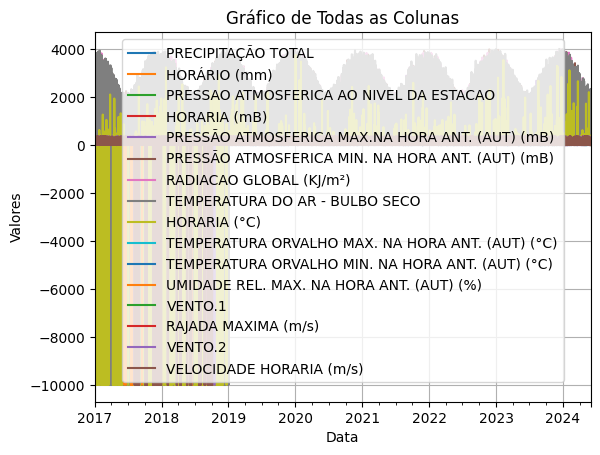

In [17]:
plt.figure(figsize=(10, 12))  # Definir o tamanho da figura
clima_poa.plot()  # Plotar todas as colunas numéricas

# Personalizar o gráfico
plt.title('Gráfico de Todas as Colunas')
plt.xlabel('Data')
plt.ylabel('Valores')
# plt.legend(clima_poa.columns, title='Colunas')  # Usar nomes das colunas como legenda
plt.grid(True)

# Exibir o gráfico
plt.show()

In [ ]:
clima_poa = clima_poa.replace(-9999, 0)
clima_poa = clima_poa.replace('-', 0)
clima_poa['Data'] = clima_poa['DATA (YYYY-MM-DD)'].astype(str) + ' ' + clima_poa['HORA (UTC)'].astype(str)
clima_poa['Data'] = pd.to_datetime(clima_poa['Data'])
clima_poa = clima_poa[['Data', 'HORÁRIO (mm)', 'HORARIA (°C)', 'UMIDADE RELATIVA DO AR', 'VENTO']]
clima_poa = clima_poa.infer_objects(copy=False).interpolate()

In [97]:
clima_poa.describe()

,Data,HORÁRIO (mm),HORARIA (°C),UMIDADE RELATIVA DO AR,VENTO
count,64992,64992.000000,64992.000000,64992.000000,64992.000000
mean,2020-09-15 23:30:00,929.118376,21.608029,11.151172,20.893433
min,2017-01-01 00:00:00,0.000000,0.000000,-3.000000,-3.000000
25%,2018-11-08 23:45:00,1004.000000,5.000000,5.000000,5.000000
50%,2020-09-15 23:30:00,1009.000000,10.000000,9.000000,10.000000
75%,2022-07-24 23:15:00,1013.000000,19.000000,16.000000,19.000000
max,2024-05-31 23:00:00,1030.000000,3757.000000,341.000000,349.000000
std,NaN,272.302918,99.842066,9.779469,27.216248
